## Day 5 – Seaborn & Plotly Advanced Visualization

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
df = pd.read_excel("/content/HR-Employee-Attrition.xlsx")

## Seaborn visualizations


## 1. Heatmap – correlation between numerical variables


In [4]:
numeric_df = df.select_dtypes(include="number")
correlation = numeric_df.corr()

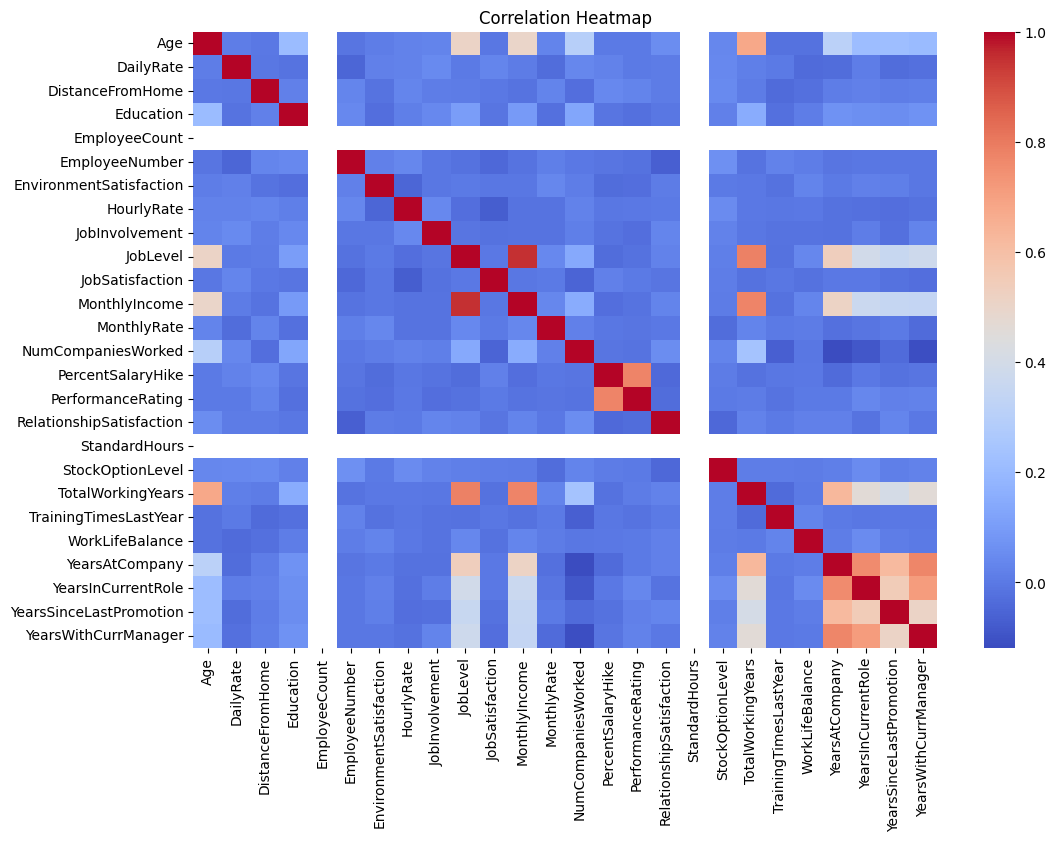

In [5]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 2. Pair plot – selected numerical columns


In [6]:
pair_columns = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany"
]

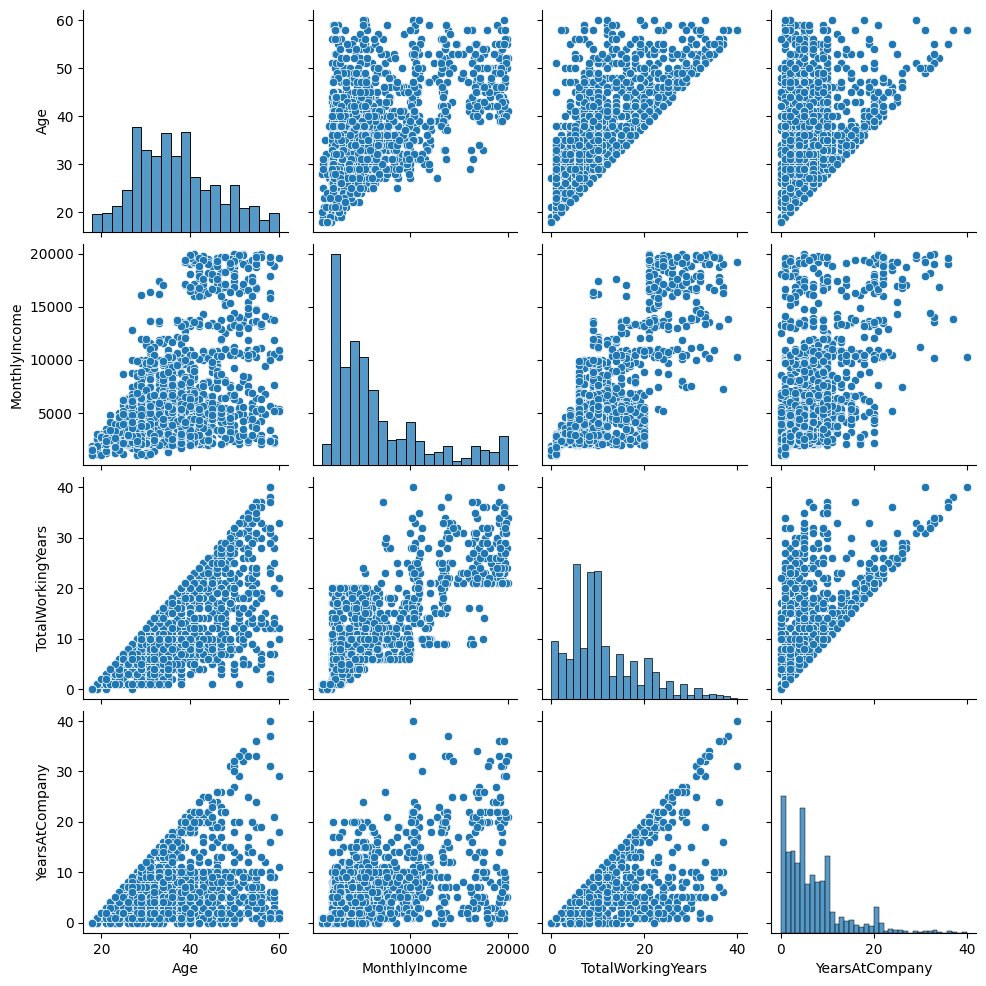

In [7]:
sns.pairplot(df[pair_columns].dropna())
plt.show()

## 3. Violin plot – MonthlyIncome by Attrition


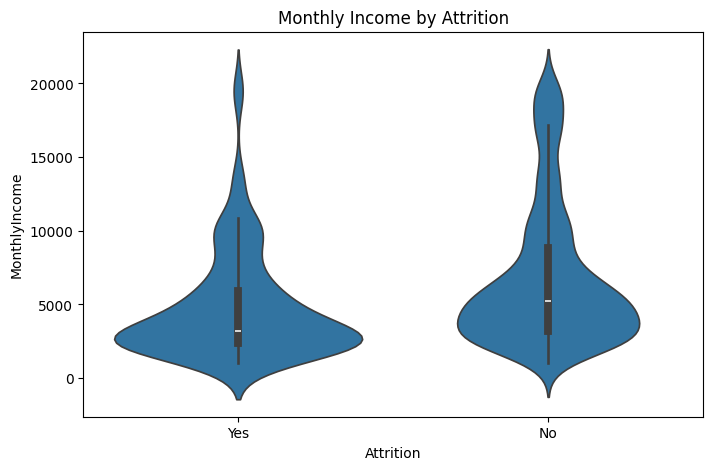

In [8]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="Attrition", y="MonthlyIncome")
plt.title("Monthly Income by Attrition")
plt.show()

## 4. Swarm plot – Job Satisfaction by Attrition


In [9]:
sample_df = df[["Attrition", "JobSatisfaction"]].dropna().sample(
    min(300, len(df)),
    random_state=42
)

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 46.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


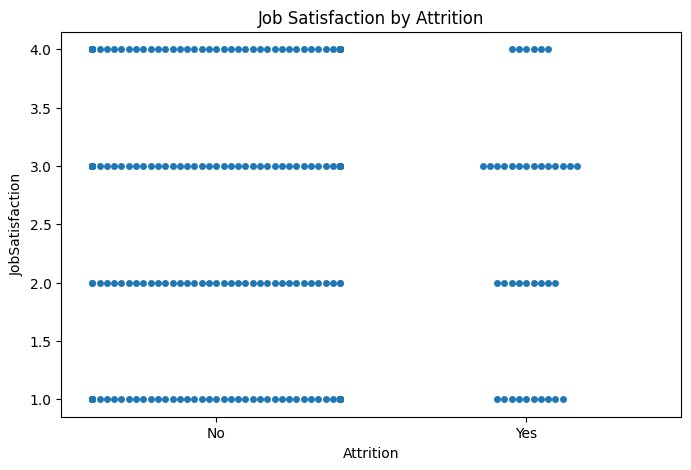

In [10]:
plt.figure(figsize=(8, 5))
sns.swarmplot(data=sample_df, x="Attrition", y="JobSatisfaction")
plt.title("Job Satisfaction by Attrition")
plt.show()

## 5. Density plot – Age


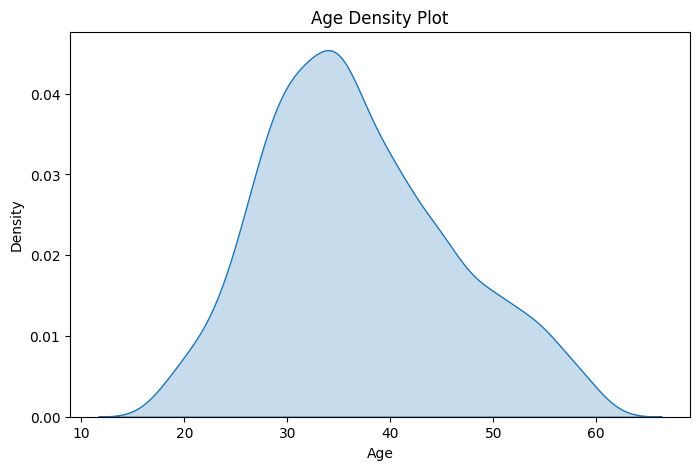

In [11]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="Age", fill=True)
plt.title("Age Density Plot")
plt.show()

## 6. Interactive scatter plot


In [12]:
fig1 = px.scatter(
    df,
    x="Age",
    y="MonthlyIncome",
    color="Attrition",
    hover_data=["JobRole", "Department"],
    title="Interactive Age vs Monthly Income"
)
fig1.show()

## 7. Interactive bar chart


In [13]:
department_summary = (
    df.groupby("Department")
    .size()
    .reset_index(name="EmployeeCount")
)

fig2 = px.bar(
    department_summary,
    x="Department",
    y="EmployeeCount",
    title="Interactive Employee Count by Department"
)
fig2.show()



## 8. Interactive line chart


In [14]:
job_level_income = (
    df.groupby("JobLevel")["MonthlyIncome"]
    .mean()
    .reset_index()
)

fig3 = px.line(
    job_level_income,
    x="JobLevel",
    y="MonthlyIncome",
    markers=True,
    title="Interactive Average Monthly Income by Job Level"
)
fig3.show()